# Preliminary Analysis
## Evaluating Rule Based Trading Strategies Against Deep Learning Benchmarks for Short Term Forex Directional Prediction

This notebook presents the data preprocessing pipeline, exploratory data analysis, and preliminary strategy signal generation for the paper.

---
## Section 1  (Project Setup)

The FX project root is added to `sys.path` so that `config.py` and all modules inside `utils/` can be imported directly from this notebook, which lives one level below the root in `notebooks/`.

In [11]:
import sys
import os

# Add the FX root directory to sys.path so config and utils are importable.
ROOT = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from config import (
    DATASET_DIR, RAW_DIR, PROCESSED_DIR, SPLITS_DIR,
    FIGURES_DIR, TABLES_DIR,
    CURRENCY_PAIRS, TIMEFRAMES, START_DATE, END_DATE,
    TRAIN_RATIO, VAL_RATIO, TEST_RATIO,
    SMA_FAST_PERIOD, SMA_SLOW_PERIOD, RSI_PERIOD, ATR_PERIOD, DONCHIAN_PERIOD,
    INPUT_DIM, FEATURE_NAMES,
    MA_N_S, MA_N_L, RSI_OVERSOLD, RSI_OVERBOUGHT, VB_K,
)

plt.style.use('seaborn-v0_8')
pd.set_option('display.float_format', '{:.4f}'.format)

print('Setup complete. Project root:', ROOT)

Setup complete. Project root: g:\My Drive\FX


---
## Section 2 (Data Extraction and Loading)

Raw data is sourced from [HistData.com](https://www.histdata.com) at **1-minute resolution** for two currency pairs  (**EURUSD** and **GBPUSD**) covering **January 2020 to December 2024**. Each year is supplied as a separate zip archive, giving ten zip files in total. These are extracted and the yearly CSV files are merged into two master DataFrames, one per pair, sorted chronologically and filtered to the configured date window.

In [12]:
from utils.data_loader import extract_zips, merge_pair

# Extract all zip archives into data/raw/
extract_zips(DATASET_DIR, RAW_DIR)

# Merge yearly CSVs into one master DataFrame per pair
print('\n--- EURUSD ---')
df_eurusd_raw = merge_pair(RAW_DIR, 'EURUSD')

print('--- GBPUSD ---')
df_gbpusd_raw = merge_pair(RAW_DIR, 'GBPUSD')

Extracting: HISTDATA_COM_ASCII_EURUSD_M12020.zip
Extracting: HISTDATA_COM_ASCII_EURUSD_M12021.zip
Extracting: HISTDATA_COM_ASCII_EURUSD_M12022.zip
Extracting: HISTDATA_COM_ASCII_EURUSD_M12023.zip
Extracting: HISTDATA_COM_ASCII_EURUSD_M12024.zip
Extracting: HISTDATA_COM_ASCII_GBPUSD_M12020.zip
Extracting: HISTDATA_COM_ASCII_GBPUSD_M12021.zip
Extracting: HISTDATA_COM_ASCII_GBPUSD_M12022.zip
Extracting: HISTDATA_COM_ASCII_GBPUSD_M12023.zip
Extracting: HISTDATA_COM_ASCII_GBPUSD_M12024.zip
Extraction complete.


--- EURUSD ---
  Loading: DAT_ASCII_EURUSD_M1_2020.csv
  Loading: DAT_ASCII_EURUSD_M1_2021.csv
  Loading: DAT_ASCII_EURUSD_M1_2022.csv
  Loading: DAT_ASCII_EURUSD_M1_2023.csv
  Loading: DAT_ASCII_EURUSD_M1_2024.csv

EURUSD merged: 1,809,479 rows | 2020-01-01 to 2024-12-31

--- GBPUSD ---
  Loading: DAT_ASCII_GBPUSD_M1_2020.csv
  Loading: DAT_ASCII_GBPUSD_M1_2021.csv
  Loading: DAT_ASCII_GBPUSD_M1_2022.csv
  Loading: DAT_ASCII_GBPUSD_M1_2023.csv
  Loading: DAT_ASCII_GBPUSD_M1_2024.cs

In [13]:
# Preview raw data
print('EURUSD raw shape:', df_eurusd_raw.shape)
print('GBPUSD raw shape:', df_gbpusd_raw.shape)

print('\n--- EURUSD first 10 rows ---')
display(df_eurusd_raw.head(10))

print('\n--- GBPUSD first 10 rows ---')
display(df_gbpusd_raw.head(10))

print('\n--- EURUSD descriptive statistics ---')
display(df_eurusd_raw.describe())

print('\n--- GBPUSD descriptive statistics ---')
display(df_gbpusd_raw.describe())

EURUSD raw shape: (1809479, 5)
GBPUSD raw shape: (1810223, 5)

--- EURUSD first 10 rows ---


,Open,High,Low,Close,Volume
DateTime,,,,,
2020-01-01 17:00:00,1.1212,1.1212,1.1212,1.1212,0
2020-01-01 17:01:00,1.1211,1.1214,1.1211,1.1214,0
2020-01-01 17:02:00,1.1214,1.1214,1.1214,1.1214,0
2020-01-01 17:03:00,1.1214,1.1214,1.1212,1.1212,0
2020-01-01 17:04:00,1.1212,1.1213,1.1212,1.1213,0
2020-01-01 17:05:00,1.1213,1.1213,1.1213,1.1213,0
2020-01-01 17:06:00,1.1213,1.1213,1.1213,1.1213,0
2020-01-01 17:07:00,1.1213,1.1213,1.1213,1.1213,0
2020-01-01 17:08:00,1.1213,1.1213,1.1213,1.1213,0



--- GBPUSD first 10 rows ---


,Open,High,Low,Close,Volume
DateTime,,,,,
2020-01-01 17:02:00,1.3246,1.3246,1.3246,1.3246,0
2020-01-01 17:03:00,1.3246,1.3247,1.3246,1.3247,0
2020-01-01 17:04:00,1.3247,1.3247,1.3246,1.3246,0
2020-01-01 17:05:00,1.3247,1.3247,1.3246,1.3246,0
2020-01-01 17:06:00,1.3246,1.3247,1.3246,1.3246,0
2020-01-01 17:07:00,1.3246,1.3246,1.3246,1.3246,0
2020-01-01 17:08:00,1.3246,1.3247,1.3246,1.3247,0
2020-01-01 17:09:00,1.3247,1.3247,1.3246,1.3247,0
2020-01-01 17:10:00,1.3246,1.3248,1.3246,1.3247,0



--- EURUSD descriptive statistics ---


,Open,High,Low,Close,Volume
count,1809479.0000,1809479.0000,1809479.0000,1809479.0000,1809479.0000
mean,1.1087,1.1088,1.1086,1.1087,0.0000
std,0.0587,0.0587,0.0587,0.0587,0.0000
min,0.9538,0.9543,0.9536,0.9538,0.0000
25%,1.0729,1.0729,1.0728,1.0729,0.0000
50%,1.0941,1.0941,1.0940,1.0941,0.0000
75%,1.1600,1.1601,1.1600,1.1600,0.0000
max,1.2349,1.2349,1.2348,1.2349,0.0000



--- GBPUSD descriptive statistics ---


,Open,High,Low,Close,Volume
count,1810223.0000,1810223.0000,1810223.0000,1810223.0000,1810223.0000
mean,1.2844,1.2845,1.2842,1.2844,0.0000
std,0.0659,0.0658,0.0659,0.0659,0.0000
min,1.0362,1.0392,1.0326,1.0362,0.0000
25%,1.2425,1.2426,1.2424,1.2425,0.0000
50%,1.2750,1.2751,1.2749,1.2750,0.0000
75%,1.3328,1.3329,1.3326,1.3328,0.0000
max,1.4246,1.4249,1.4244,1.4246,0.0000


In [14]:
# Raw data summary table
raw_summary = pd.DataFrame([
    {
        'Pair':           pair,
        'Total Rows':     len(df),
        'Start Date':     df.index.min().date(),
        'End Date':       df.index.max().date(),
        'Missing Values': df.isnull().sum().sum(),
    }
    for pair, df in [('EURUSD', df_eurusd_raw), ('GBPUSD', df_gbpusd_raw)]
])
display(raw_summary)

,Pair,Total Rows,Start Date,End Date,Missing Values
0,EURUSD,1809479,2020-01-01,2024-12-31,0
1,GBPUSD,1810223,2020-01-01,2024-12-31,0


---
## Section 3 (Data Cleaning)

Three cleaning steps are applied sequentially to each raw 1-minute DataFrame:

1. **Weekend removal** Forex markets are closed Saturday and Sunday. Any rows timestamped on those days are artefacts and are discarded.
2. **Low-liquidity period removal** Two thin-market windows are excluded, Friday 21:00–23:59 UTC (wind-down before weekend close) and Monday 00:00–01:00 UTC (illiquid period just after market open). Spreads widen substantially during these windows, making signals unreliable.
3. **Missing value handling** A complete 1-minute reference grid is built for the cleaned trading hours. Gaps of up to **3 consecutive bars** are forward-filled (carrying the last known price). Gaps larger than 3 bars are dropped entirely, as they likely represent exchange outages or data feed failures that cannot be reliably imputed.

In [15]:
from utils.preprocessor import remove_weekends

print('--- EURUSD ---')
n_before_eu = len(df_eurusd_raw)
df_eurusd_wd = remove_weekends(df_eurusd_raw)
print(f'  Rows before: {n_before_eu:,}  |  Rows after: {len(df_eurusd_wd):,}')

print('\n--- GBPUSD ---')
n_before_gb = len(df_gbpusd_raw)
df_gbpusd_wd = remove_weekends(df_gbpusd_raw)
print(f'  Rows before: {n_before_gb:,}  |  Rows after: {len(df_gbpusd_wd):,}')

--- EURUSD ---
  remove_weekends: removed 106,128 rows (1,703,351 remaining)
  Rows before: 1,809,479  |  Rows after: 1,703,351

--- GBPUSD ---
  remove_weekends: removed 105,686 rows (1,704,537 remaining)
  Rows before: 1,810,223  |  Rows after: 1,704,537


In [16]:
from utils.preprocessor import remove_low_liquidity

print('--- EURUSD ---')
n_before_eu = len(df_eurusd_wd)
df_eurusd_lq = remove_low_liquidity(df_eurusd_wd)
print(f'  Rows before: {n_before_eu:,}  |  Rows after: {len(df_eurusd_lq):,}')

print('\n--- GBPUSD ---')
n_before_gb = len(df_gbpusd_wd)
df_gbpusd_lq = remove_low_liquidity(df_gbpusd_wd)
print(f'  Rows before: {n_before_gb:,}  |  Rows after: {len(df_gbpusd_lq):,}')

--- EURUSD ---
  remove_low_liquidity: removed 15,652 rows (1,687,699 remaining)
  Rows before: 1,703,351  |  Rows after: 1,687,699

--- GBPUSD ---
  remove_low_liquidity: removed 15,690 rows (1,688,847 remaining)
  Rows before: 1,704,537  |  Rows after: 1,688,847


In [17]:
from utils.preprocessor import handle_missing

print('--- EURUSD ---')
df_eurusd_1m = handle_missing(df_eurusd_lq)

print('\n--- GBPUSD ---')
df_gbpusd_1m = handle_missing(df_gbpusd_lq)

--- EURUSD ---
  handle_missing: 127,159 gap bars found | 11,193 forward-filled | 115,966 dropped (gaps > 3 bars) | 1,698,892 rows remaining

--- GBPUSD ---
  handle_missing: 126,009 gap bars found | 9,130 forward-filled | 116,879 dropped (gaps > 3 bars) | 1,697,977 rows remaining


In [18]:
# Cleaning summary table
cleaning_summary = pd.DataFrame([
    {
        'Pair':                    'EURUSD',
        'Raw Rows':                len(df_eurusd_raw),
        'After Weekend Removal':   len(df_eurusd_wd),
        'After Liquidity Filter':  len(df_eurusd_lq),
        'Final Rows':              len(df_eurusd_1m),
        'Rows Dropped Total':      len(df_eurusd_raw) - len(df_eurusd_1m),
    },
    {
        'Pair':                    'GBPUSD',
        'Raw Rows':                len(df_gbpusd_raw),
        'After Weekend Removal':   len(df_gbpusd_wd),
        'After Liquidity Filter':  len(df_gbpusd_lq),
        'Final Rows':              len(df_gbpusd_1m),
        'Rows Dropped Total':      len(df_gbpusd_raw) - len(df_gbpusd_1m),
    },
])
display(cleaning_summary)

,Pair,Raw Rows,After Weekend Removal,After Liquidity Filter,Final Rows,Rows Dropped Total
0,EURUSD,1809479,1703351,1687699,1698892,110587
1,GBPUSD,1810223,1704537,1688847,1697977,112246


---
## Section 4 (Resampling)

The cleaned 1-minute data is resampled to **15-minute** and **1-hour** OHLCV bars using standard aggregation rules, Open = first, High = max, Low = min, Close = last, Volume = sum. Incomplete bars (those with any NaN value after aggregation) are dropped. This produces **four working datasets** that serve as the basis for all subsequent analysis, feature engineering, and model training:

| Dataset | Pair | Timeframe |
|---|---|---|
| `eurusd_15min` | EURUSD | 15-minute |
| `eurusd_1H` | EURUSD | 1-hour |
| `gbpusd_15min` | GBPUSD | 15-minute |
| `gbpusd_1H` | GBPUSD | 1-hour |

In [19]:
from utils.preprocessor import resample_ohlcv

print('--- Resampling EURUSD ---')
eurusd_15min = resample_ohlcv(df_eurusd_1m, '15min')
eurusd_1H    = resample_ohlcv(df_eurusd_1m, '1h')

print('\n--- Resampling GBPUSD ---')
gbpusd_15min = resample_ohlcv(df_gbpusd_1m, '15min')
gbpusd_1H    = resample_ohlcv(df_gbpusd_1m, '1h')

print('\nShapes:')
for name, df in [('eurusd_15min', eurusd_15min), ('eurusd_1H', eurusd_1H),
                 ('gbpusd_15min', gbpusd_15min), ('gbpusd_1H', gbpusd_1H)]:
    print(f'  {name}: {df.shape}')

--- Resampling EURUSD ---
  resample_ohlcv in]: 114,058 bars (61,238 incomplete bars dropped)
  resample_ohlcv [1h]: 29,206 bars (14,618 incomplete bars dropped)

--- Resampling GBPUSD ---
  resample_ohlcv in]: 113,994 bars (61,302 incomplete bars dropped)
  resample_ohlcv [1h]: 29,191 bars (14,633 incomplete bars dropped)

Shapes:
  eurusd_15min: (114058, 5)
  eurusd_1H: (29206, 5)
  gbpusd_15min: (113994, 5)
  gbpusd_1H: (29191, 5)


In [20]:
# Preview resampled data
for name, df in [('eurusd_15min', eurusd_15min), ('eurusd_1H', eurusd_1H),
                 ('gbpusd_15min', gbpusd_15min), ('gbpusd_1H', gbpusd_1H)]:
    print(f'\n--- {name} ---')
    display(df.head(5))


--- eurusd_15min ---


,Open,High,Low,Close,Volume
2020-01-01 17:00:00,1.1212,1.1214,1.1211,1.1213,0.0000
2020-01-01 17:15:00,1.1213,1.1215,1.1213,1.1215,0.0000
2020-01-01 17:30:00,1.1215,1.1216,1.1214,1.1215,0.0000
2020-01-01 17:45:00,1.1216,1.1217,1.1214,1.1214,0.0000
2020-01-01 18:00:00,1.1214,1.1222,1.1214,1.1220,0.0000



--- eurusd_1H ---


,Open,High,Low,Close,Volume
2020-01-01 17:00:00,1.1212,1.1217,1.1211,1.1214,0.0000
2020-01-01 18:00:00,1.1214,1.1222,1.1214,1.1219,0.0000
2020-01-01 19:00:00,1.1219,1.1219,1.1216,1.1218,0.0000
2020-01-01 20:00:00,1.1218,1.1224,1.1218,1.1221,0.0000
2020-01-01 21:00:00,1.1221,1.1224,1.1218,1.1222,0.0000



--- gbpusd_15min ---


,Open,High,Low,Close,Volume
2020-01-01 17:00:00,1.3246,1.3248,1.3246,1.3247,0.0000
2020-01-01 17:15:00,1.3247,1.3254,1.3246,1.3251,0.0000
2020-01-01 17:30:00,1.3251,1.3251,1.3247,1.3250,0.0000
2020-01-01 17:45:00,1.3251,1.3255,1.3246,1.3247,0.0000
2020-01-01 18:00:00,1.3247,1.3261,1.3247,1.3257,0.0000



--- gbpusd_1H ---


,Open,High,Low,Close,Volume
2020-01-01 17:00:00,1.3246,1.3255,1.3246,1.3247,0.0000
2020-01-01 18:00:00,1.3247,1.3261,1.3247,1.3250,0.0000
2020-01-01 19:00:00,1.3250,1.3262,1.3247,1.3256,0.0000
2020-01-01 20:00:00,1.3256,1.3266,1.3253,1.3256,0.0000
2020-01-01 21:00:00,1.3255,1.3256,1.3243,1.3248,0.0000


In [21]:
# Resampling summary table
datasets = [
    ('EURUSD', '15min', eurusd_15min),
    ('EURUSD', '1h',    eurusd_1H),
    ('GBPUSD', '15min', gbpusd_15min),
    ('GBPUSD', '1h',    gbpusd_1H),
]

resample_summary = pd.DataFrame([
    {
        'Pair':            pair,
        'Timeframe':       tf,
        'Bars':            len(df),
        'Start':           df.index.min().date(),
        'End':             df.index.max().date(),
        'Avg Daily Bars':  round(len(df) / ((df.index.max() - df.index.min()).days + 1), 1),
    }
    for pair, tf, df in datasets
])
display(resample_summary)

,Pair,Timeframe,Bars,Start,End,Avg Daily Bars
0,EURUSD,15min,114058,2020-01-01,2024-12-31,62.5000
1,EURUSD,1h,29206,2020-01-01,2024-12-31,16.0000
2,GBPUSD,15min,113994,2020-01-01,2024-12-31,62.4000
3,GBPUSD,1h,29191,2020-01-01,2024-12-31,16.0000


---
## Section 5 (Exploratory Data Analysis)

This section examines the statistical properties of the four datasets, including price distributions, log-return distributions, and rolling volatility characteristics across the full 2020–2024 study period. Key market regimes  (the COVID-19 shock in early 2020 and the aggressive rate-hiking cycle beginning in early 2022) are highlighted on all time-series plots.

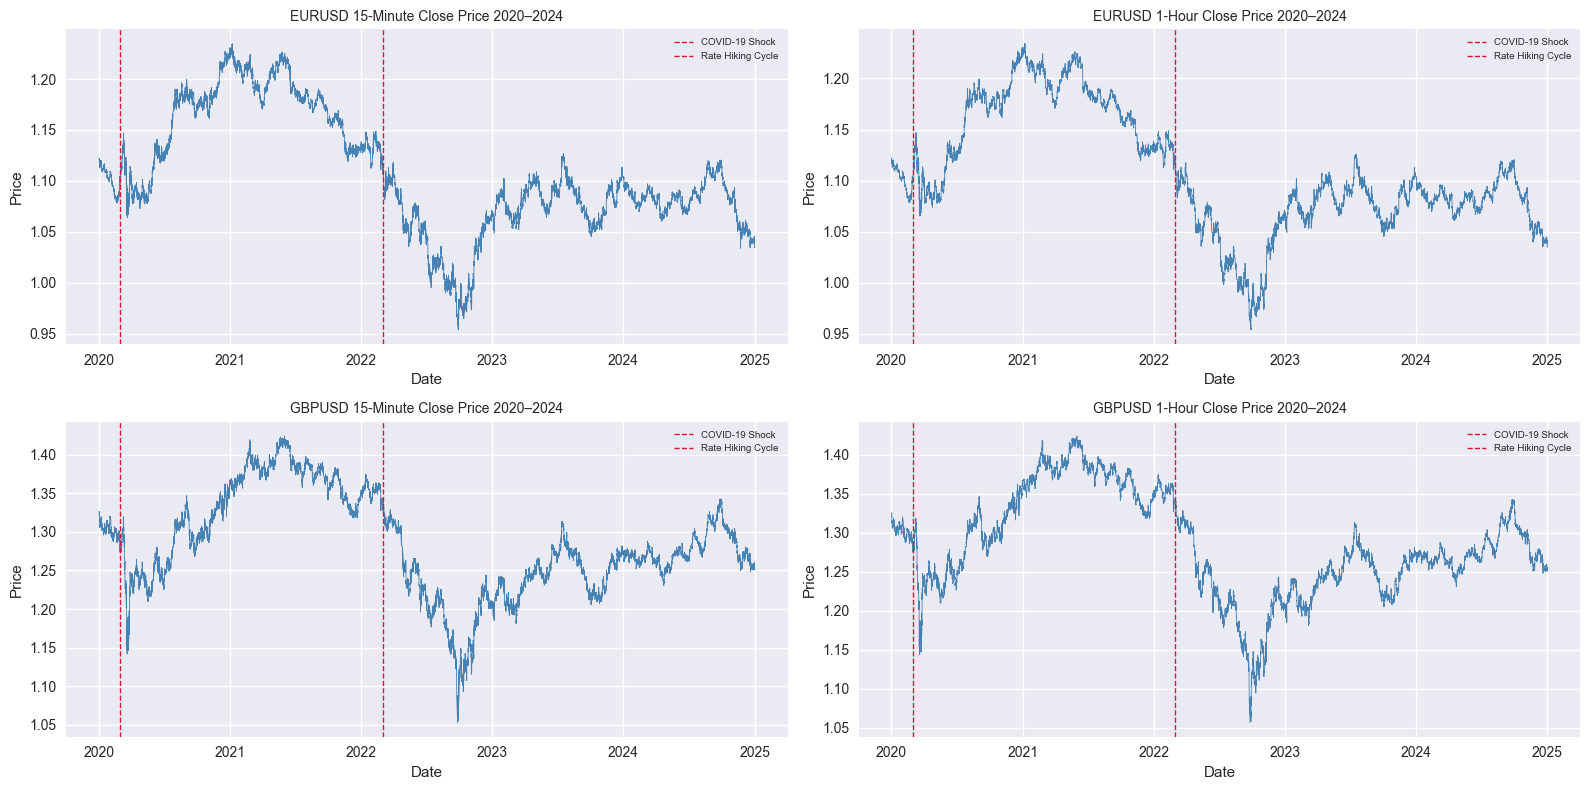

Saved: price_charts.png


In [ ]:
# Price charts  (2x2 grid, one per dataset)
events = [
    ('2020-03-01', 'COVID-19 Shock'),
    ('2022-03-01', 'Rate Hiking Cycle'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=False)
plot_data = [
    ('EURUSD 15-Minute Close Price 2020–2024', eurusd_15min),
    ('EURUSD 1-Hour Close Price 2020–2024',    eurusd_1H),
    ('GBPUSD 15-Minute Close Price 2020–2024', gbpusd_15min),
    ('GBPUSD 1-Hour Close Price 2020–2024',    gbpusd_1H),
]

for ax, (title, df) in zip(axes.flat, plot_data):
    ax.plot(df.index, df['Close'], linewidth=0.6, color='steelblue')
    for date_str, label in events:
        ax.axvline(pd.Timestamp(date_str), color='crimson',
                   linestyle='--', linewidth=1.0, label=label)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Date')
    ax.set_ylabel('Price')
    ax.legend(fontsize=7)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'price_charts.png'), dpi=150)
plt.show()
print('Saved: price_charts.png')

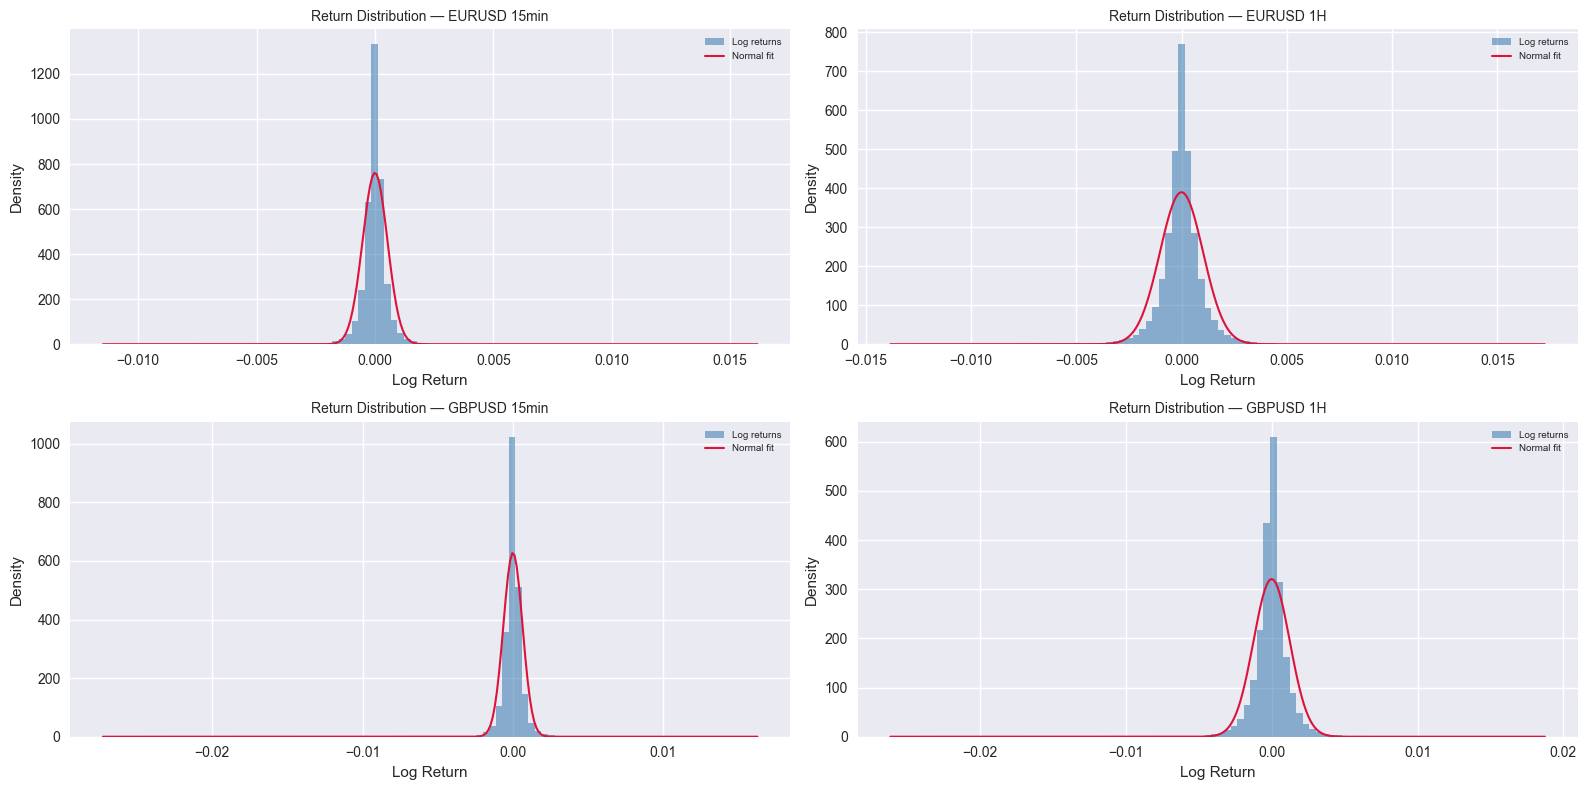

Saved: return_distributions.png


In [ ]:
# Return distributions (histogram with normal overlay)
from scipy.stats import norm

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
ret_data = [
    ('EURUSD 15min', eurusd_15min),
    ('EURUSD 1H',    eurusd_1H),
    ('GBPUSD 15min', gbpusd_15min),
    ('GBPUSD 1H',    gbpusd_1H),
]

log_returns = {}
for ax, (label, df) in zip(axes.flat, ret_data):
    lr = np.log(df['Close'] / df['Close'].shift(1)).dropna()
    log_returns[label] = lr
    ax.hist(lr, bins=100, density=True, alpha=0.6, color='steelblue',
            label='Log returns')
    mu, sigma = lr.mean(), lr.std()
    x = np.linspace(lr.min(), lr.max(), 300)
    ax.plot(x, norm.pdf(x, mu, sigma), color='crimson',
            linewidth=1.5, label='Normal fit')
    ax.set_title(f'Return Distribution — {label}', fontsize=10)
    ax.set_xlabel('Log Return')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'return_distributions.png'), dpi=150)
plt.show()
print('Saved: return_distributions.png')

In [24]:
# Descriptive statistics table
from scipy.stats import skew, kurtosis

stats_rows = []
for label, lr in log_returns.items():
    stats_rows.append({
        'Dataset':      label,
        'Mean Return':  lr.mean(),
        'Std Return':   lr.std(),
        'Skewness':     skew(lr),
        'Kurtosis':     kurtosis(lr),
        'Min':          lr.min(),
        'Max':          lr.max(),
    })

display(pd.DataFrame(stats_rows).set_index('Dataset'))

,Mean Return,Std Return,Skewness,Kurtosis,Min,Max
Dataset,,,,,,
EURUSD 15min,-0.0000,0.0005,0.0269,32.8834,-0.0115,0.0161
EURUSD 1H,-0.0000,0.0010,-0.0485,14.7328,-0.0138,0.0173
GBPUSD 15min,-0.0000,0.0006,-0.8280,58.0080,-0.0273,0.0163
GBPUSD 1H,-0.0000,0.0012,-0.3795,21.3033,-0.0261,0.0187


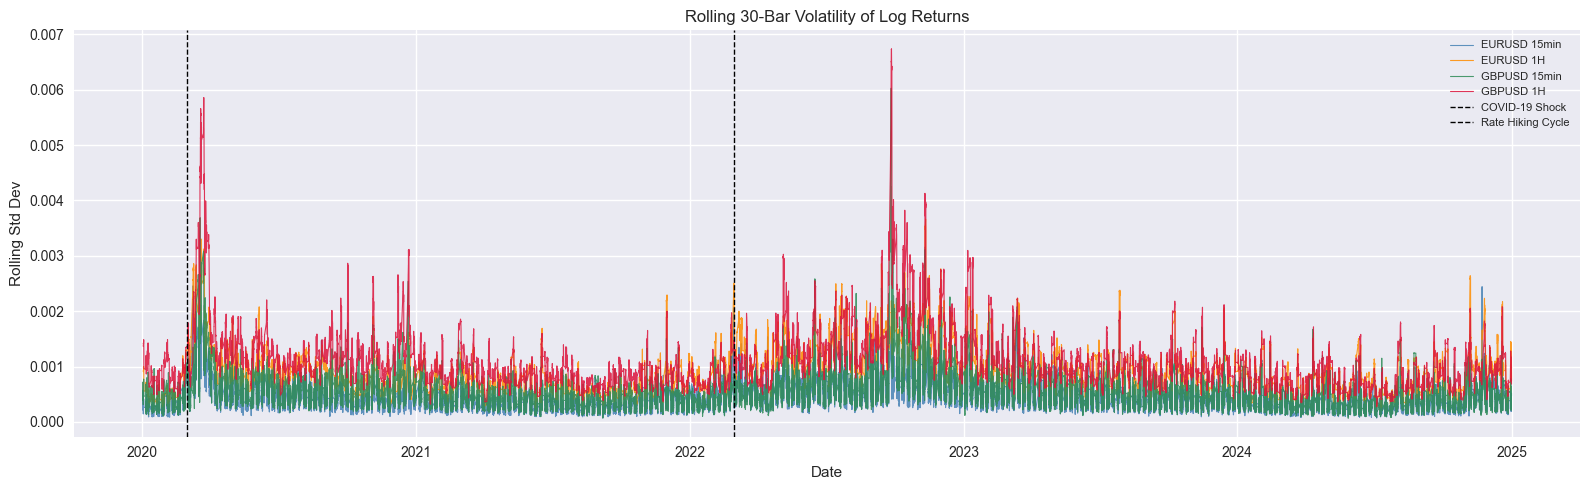

Saved: volatility.png


In [25]:
# Rolling volatility (30-bar rolling std of log returns)
fig, ax = plt.subplots(figsize=(16, 5))

colours = ['steelblue', 'darkorange', 'seagreen', 'crimson']
for (label, lr), colour in zip(log_returns.items(), colours):
    ax.plot(lr.rolling(30).std(), linewidth=0.8,
            label=label, color=colour, alpha=0.85)

for date_str, ev_label in events:
    ax.axvline(pd.Timestamp(date_str), color='black',
               linestyle='--', linewidth=1.0, label=ev_label)

ax.set_title('Rolling 30-Bar Volatility of Log Returns', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Std Dev')
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'volatility.png'), dpi=150)
plt.show()
print('Saved: volatility.png')

---
## Section 6 (Feature Engineering)

Ten features are computed for each of the four datasets, as defined in `config.py`. These form the **input feature vector of dimension m = 10** fed into the LSTM and GRU models at each time step:

| # | Feature | Description |
|---|---|---|
| 1 | Open | Raw open price |
| 2 | High | Raw high price |
| 3 | Low | Raw low price |
| 4 | Close | Raw close price |
| 5 | Volume | Tick volume |
| 6 | SMA10 | 10-period simple moving average of Close |
| 7 | SMA50 | 50-period simple moving average of Close |
| 8 | RSI14 | 14-period Relative Strength Index (Wilder smoothing) |
| 9 | ATR14 | 14-period Average True Range |
| 10 | Donchian_Width | 20-period Donchian channel width (High_max − Low_min) |

Rows where any rolling calculation produces NaN (the warm-up period at the start of each series) are dropped.

In [26]:
def compute_features(df):
    """
    Compute the ten input features defined in config.py and return the
    enriched DataFrame.  NaN rows from rolling warm-up are dropped.

    Features added:
        SMA10          — 10-period simple moving average of Close.
        SMA50          — 50-period simple moving average of Close.
        RSI14          — 14-period RSI using Wilder's smoothing
                         (Equations 10–13 in the paper).
        ATR14          — 14-period Average True Range using True Range
                         and Wilder's smoothing (Equations 18–19).
        Donchian_Width — 20-period channel width: rolling High max
                         minus rolling Low min.

    Parameters
    ----------
    df : pd.DataFrame
        OHLCV DataFrame with a DatetimeIndex.

    Returns
    -------
    pd.DataFrame
        DataFrame with all 10 features and no NaN rows.
    """
    df = df.copy()

    # SMA10 and SMA50
    df['SMA10'] = df['Close'].rolling(window=10).mean()
    df['SMA50'] = df['Close'].rolling(window=50).mean()

    # RSI14 — Wilder smoothing (equivalent to EWM with alpha = 1/period)
    delta  = df['Close'].diff()
    gain   = delta.clip(lower=0)
    loss   = (-delta).clip(lower=0)
    # Wilder's: first value is SMA, subsequent values use EWM
    avg_gain = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    df['RSI14'] = 100 - (100 / (1 + rs))

    # ATR14 — True Range then Wilder smoothing
    high_low   = df['High'] - df['Low']
    high_close = (df['High'] - df['Close'].shift(1)).abs()
    low_close  = (df['Low']  - df['Close'].shift(1)).abs()
    true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    df['ATR14'] = true_range.ewm(alpha=1/14, min_periods=14, adjust=False).mean()

    # Donchian Width — 20-period
    df['Donchian_Width'] = (
        df['High'].rolling(window=20).max() -
        df['Low'].rolling(window=20).min()
    )

    before = len(df)
    df = df.dropna()
    dropped = before - len(df)
    return df, dropped


# Apply to all four datasets
for name, df_ref in [('eurusd_15min', eurusd_15min), ('eurusd_1H', eurusd_1H),
                     ('gbpusd_15min', gbpusd_15min), ('gbpusd_1H', gbpusd_1H)]:
    before = len(df_ref)
    result, dropped = compute_features(df_ref)
    # Store back
    if name == 'eurusd_15min': eurusd_15min = result
    elif name == 'eurusd_1H':  eurusd_1H    = result
    elif name == 'gbpusd_15min': gbpusd_15min = result
    elif name == 'gbpusd_1H':   gbpusd_1H    = result
    print(f'{name}: {before:,} → {len(result):,} rows ({dropped:,} NaN rows dropped)')

eurusd_15min: 114,058 → 114,009 rows (49 NaN rows dropped)
eurusd_1H: 29,206 → 29,157 rows (49 NaN rows dropped)
gbpusd_15min: 113,994 → 113,945 rows (49 NaN rows dropped)
gbpusd_1H: 29,191 → 29,142 rows (49 NaN rows dropped)


In [27]:
# Feature preview — first 5 rows of eurusd_15min with all 10 features
display(eurusd_15min[FEATURE_NAMES].head(5))

,Open,High,Low,Close,Volume,SMA10,SMA50,RSI14,ATR14,Donchian_Width
2020-01-02 05:15:00,1.1201,1.1201,1.1193,1.1193,0.0000,1.1206,1.1212,27.6556,0.0004,0.0021
2020-01-02 05:30:00,1.1193,1.1196,1.1193,1.1194,0.0000,1.1205,1.1212,28.8291,0.0004,0.0021
2020-01-02 05:45:00,1.1194,1.1200,1.1194,1.1198,0.0000,1.1204,1.1212,38.3119,0.0004,0.0021
2020-01-02 06:00:00,1.1198,1.1202,1.1197,1.1200,0.0000,1.1203,1.1211,42.4414,0.0004,0.0021
2020-01-02 06:15:00,1.1200,1.1200,1.1194,1.1195,0.0000,1.1201,1.1211,35.6633,0.0004,0.0021


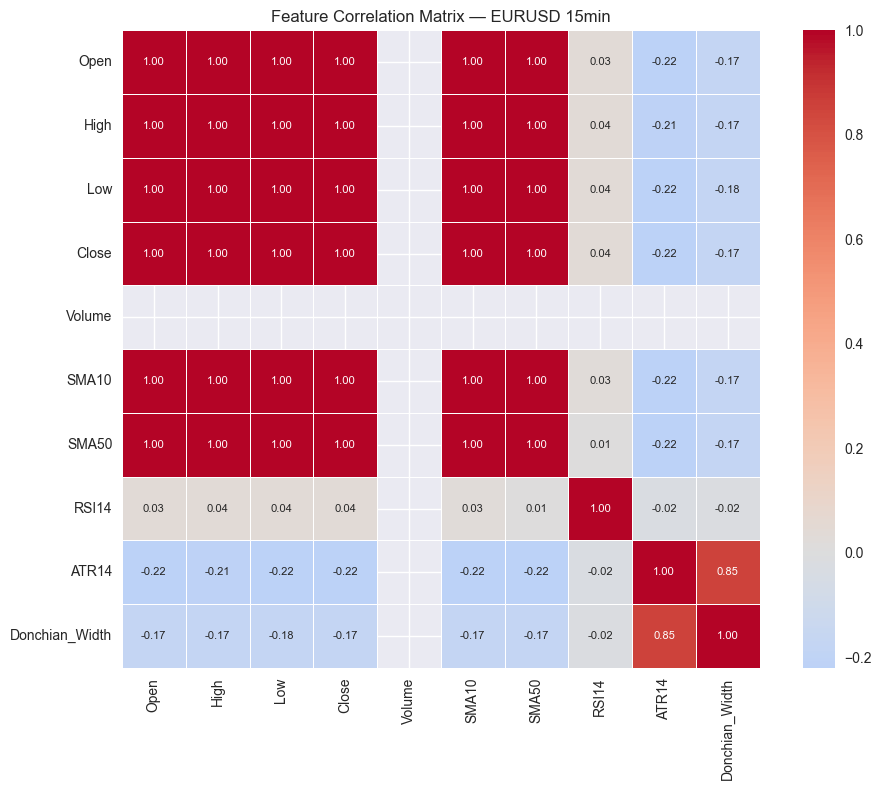

Saved: feature_correlation.png


In [28]:
# Feature correlation heatmap — eurusd_15min
corr = eurusd_15min[FEATURE_NAMES].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Feature Correlation Matrix — EURUSD 15min', fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'feature_correlation.png'), dpi=150)
plt.show()
print('Saved: feature_correlation.png')

In [29]:
# Feature statistics table — eurusd_15min
display(eurusd_15min[FEATURE_NAMES].describe())

,Open,High,Low,Close,Volume,SMA10,SMA50,RSI14,ATR14,Donchian_Width
count,114009.0000,114009.0000,114009.0000,114009.0000,114009.0000,114009.0000,114009.0000,114009.0000,114009.0000,114009.0000
mean,1.1087,1.1090,1.1083,1.1087,0.0000,1.1087,1.1087,50.0495,0.0007,0.0034
std,0.0586,0.0585,0.0586,0.0586,0.0000,0.0586,0.0585,12.0054,0.0003,0.0023
min,0.9539,0.9552,0.9536,0.9539,0.0000,0.9554,0.9561,5.4780,0.0001,0.0004
25%,1.0729,1.0732,1.0726,1.0729,0.0000,1.0729,1.0728,41.9248,0.0005,0.0018
50%,1.0941,1.0944,1.0938,1.0941,0.0000,1.0941,1.0941,50.0504,0.0006,0.0028
75%,1.1600,1.1602,1.1597,1.1600,0.0000,1.1600,1.1600,58.2080,0.0009,0.0043
max,1.2347,1.2349,1.2343,1.2347,0.0000,1.2341,1.2325,93.4513,0.0036,0.0250


---
## Section 7 (Target Variable Generation)

The target variable **D(t)** is a binary directional label defined as:

$$D(t) = \begin{cases} +1 & \text{if } Close(t+1) > Close(t) \\ -1 & \text{otherwise} \end{cases}$$

This is consistent with **Equation 1** in the paper. Ties (where the next close equals the current close) are assigned **+1**. The final row of each series is dropped because the next close is unknown.

In [30]:
# Generate target variable for all four datasets
target_data = [
    ('eurusd_15min', eurusd_15min),
    ('eurusd_1H',    eurusd_1H),
    ('gbpusd_15min', gbpusd_15min),
    ('gbpusd_1H',    gbpusd_1H),
]

for name, df in target_data:
    df['Target'] = np.sign(df['Close'].shift(-1) - df['Close'])
    df['Target'] = df['Target'].replace(0, 1)   # ties → +1
    df.dropna(subset=['Target'], inplace=True)
    df['Target'] = df['Target'].astype(int)

    counts = df['Target'].value_counts().sort_index()
    total  = len(df)
    print(f'{name}:  total={total:,}  '
          f'+1={counts.get(1,0):,} ({counts.get(1,0)/total*100:.1f}%)  '
          f'-1={counts.get(-1,0):,} ({counts.get(-1,0)/total*100:.1f}%)')

# Refresh references after in-place mutation
eurusd_15min = target_data[0][1]
eurusd_1H    = target_data[1][1]
gbpusd_15min = target_data[2][1]
gbpusd_1H    = target_data[3][1]

eurusd_15min:  total=114,008  +1=58,539 (51.3%)  -1=55,469 (48.7%)
eurusd_1H:  total=29,156  +1=15,179 (52.1%)  -1=13,977 (47.9%)
gbpusd_15min:  total=113,944  +1=58,153 (51.0%)  -1=55,791 (49.0%)
gbpusd_1H:  total=29,141  +1=15,054 (51.7%)  -1=14,087 (48.3%)


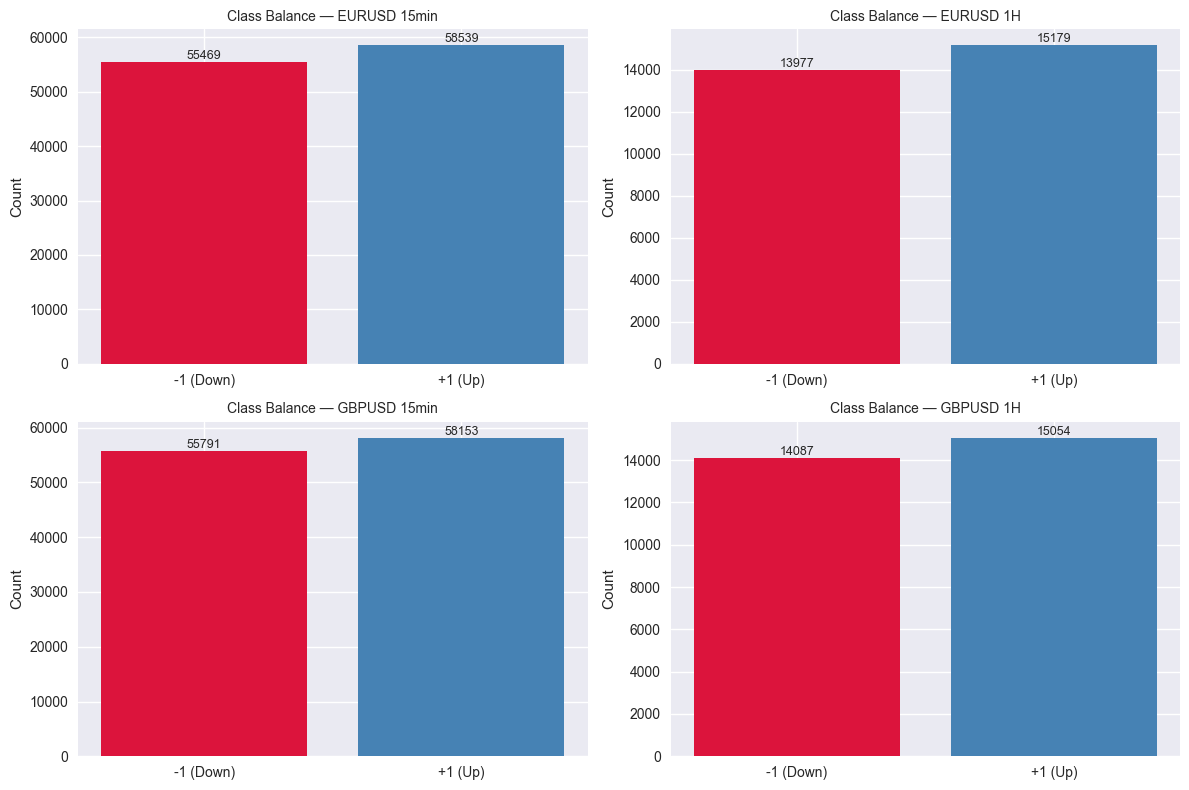

Saved: class_balance.png


In [31]:
# Class balance bar charts — 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (name, df) in zip(axes.flat, [
    ('EURUSD 15min', eurusd_15min), ('EURUSD 1H', eurusd_1H),
    ('GBPUSD 15min', gbpusd_15min), ('GBPUSD 1H', gbpusd_1H),
]):
    counts = df['Target'].value_counts().sort_index()
    bars = ax.bar(['-1 (Down)', '+1 (Up)'],
                  [counts.get(-1, 0), counts.get(1, 0)],
                  color=['crimson', 'steelblue'])
    ax.bar_label(bars, fmt='%d', fontsize=9)
    ax.set_title(f'Class Balance — {name}', fontsize=10)
    ax.set_ylabel('Count')

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'class_balance.png'), dpi=150)
plt.show()
print('Saved: class_balance.png')

---
## Section 8 (Train / Validation / Test Split)

A **strict chronological split** is applied to each of the four datasets to prevent any lookahead bias:

| Split | Proportion | Purpose |
|---|---|---|
| Training | 70% | Model fitting |
| Validation | 15% | Hyperparameter selection and early stopping |
| Test | 15% | Final evaluation (held out until reporting) |

No shuffling is applied. Rows are split by position so that earlier bars are always in training and later bars are always in validation/test. This split is **identical for all five models** (three rule-based, two deep learning) to ensure a fair comparison.

In [32]:
def chronological_split(df):
    """Split df chronologically into train, val, test by row count."""
    n = len(df)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
    train = df.iloc[:n_train]
    val   = df.iloc[n_train : n_train + n_val]
    test  = df.iloc[n_train + n_val:]
    return train, val, test


splits = {}
for name, df in [('EURUSD_15min', eurusd_15min), ('EURUSD_1H', eurusd_1H),
                 ('GBPUSD_15min', gbpusd_15min), ('GBPUSD_1H', gbpusd_1H)]:
    train, val, test = chronological_split(df)
    splits[name] = {'train': train, 'val': val, 'test': test}
    print(f'\n{name}:')
    print(f'  Train: {train.index.min().date()} → {train.index.max().date()}  ({len(train):,} bars)')
    print(f'  Val:   {val.index.min().date()} → {val.index.max().date()}    ({len(val):,} bars)')
    print(f'  Test:  {test.index.min().date()} → {test.index.max().date()}   ({len(test):,} bars)')


EURUSD_15min:
  Train: 2020-01-02 → 2023-07-07  (79,805 bars)
  Val:   2023-07-07 → 2024-04-08    (17,101 bars)
  Test:  2024-04-08 → 2024-12-31   (17,102 bars)

EURUSD_1H:
  Train: 2020-01-06 → 2023-07-04  (20,409 bars)
  Val:   2023-07-04 → 2024-04-03    (4,373 bars)
  Test:  2024-04-03 → 2024-12-31   (4,374 bars)

GBPUSD_15min:
  Train: 2020-01-02 → 2023-07-10  (79,760 bars)
  Val:   2023-07-10 → 2024-04-08    (17,091 bars)
  Test:  2024-04-08 → 2024-12-31   (17,093 bars)

GBPUSD_1H:
  Train: 2020-01-06 → 2023-07-04  (20,398 bars)
  Val:   2023-07-04 → 2024-04-03    (4,371 bars)
  Test:  2024-04-03 → 2024-12-31   (4,372 bars)


In [33]:
# Split summary table
split_rows = []
for name, s in splits.items():
    split_rows.append({
        'Dataset':    name,
        'Train Bars': len(s['train']),
        'Val Bars':   len(s['val']),
        'Test Bars':  len(s['test']),
        'Total':      len(s['train']) + len(s['val']) + len(s['test']),
    })
display(pd.DataFrame(split_rows).set_index('Dataset'))

,Train Bars,Val Bars,Test Bars,Total
Dataset,,,,
EURUSD_15min,79805,17101,17102,114008
EURUSD_1H,20409,4373,4374,29156
GBPUSD_15min,79760,17091,17093,113944
GBPUSD_1H,20398,4371,4372,29141


In [34]:
from utils.preprocessor import save_processed

# Save full featured datasets to data/processed/
for (pair, tf, df) in [
    ('EURUSD', '15min', eurusd_15min),
    ('EURUSD', '1h',    eurusd_1H),
    ('GBPUSD', '15min', gbpusd_15min),
    ('GBPUSD', '1h',    gbpusd_1H),
]:
    save_processed(df, pair, tf)

# Save train/val/test splits to data/splits/
for name, s in splits.items():
    for split_name, split_df in s.items():
        out_path = os.path.join(SPLITS_DIR, f'{name}_{split_name}.csv')
        split_df.to_csv(out_path)
        print(f'Saved: {out_path}  ({len(split_df):,} rows)')

  Saved: G:\My Drive\FX\data\processed\EURUSD_15min.csv  (114,008 rows)
  Saved: G:\My Drive\FX\data\processed\EURUSD_1h.csv  (29,156 rows)
  Saved: G:\My Drive\FX\data\processed\GBPUSD_15min.csv  (113,944 rows)
  Saved: G:\My Drive\FX\data\processed\GBPUSD_1h.csv  (29,141 rows)
Saved: G:\My Drive\FX\data\splits\EURUSD_15min_train.csv  (79,805 rows)
Saved: G:\My Drive\FX\data\splits\EURUSD_15min_val.csv  (17,101 rows)
Saved: G:\My Drive\FX\data\splits\EURUSD_15min_test.csv  (17,102 rows)
Saved: G:\My Drive\FX\data\splits\EURUSD_1H_train.csv  (20,409 rows)
Saved: G:\My Drive\FX\data\splits\EURUSD_1H_val.csv  (4,373 rows)
Saved: G:\My Drive\FX\data\splits\EURUSD_1H_test.csv  (4,374 rows)
Saved: G:\My Drive\FX\data\splits\GBPUSD_15min_train.csv  (79,760 rows)
Saved: G:\My Drive\FX\data\splits\GBPUSD_15min_val.csv  (17,091 rows)
Saved: G:\My Drive\FX\data\splits\GBPUSD_15min_test.csv  (17,093 rows)
Saved: G:\My Drive\FX\data\splits\GBPUSD_1H_train.csv  (20,398 rows)
Saved: G:\My Drive\FX\d

---
## Section 9 — Preliminary Strategy Signals

This section demonstrates each of the three rule-based strategies generating signals on real **EURUSD 15-minute** data over a 200-bar window. This is a visual sanity check to confirm that strategy logic is correctly implemented before formal evaluation. The three strategies are:

1. **MA Crossover** — Buy when the fast SMA (10) crosses above the slow SMA (50), sell when it crosses below.
2. **RSI Threshold** — Buy when RSI14 < 30 (oversold), sell when RSI14 > 70 (overbought).
3. **Volatility Breakout** — Buy when Close breaks above the 20-period Donchian upper band, sell when it breaks below the lower band.

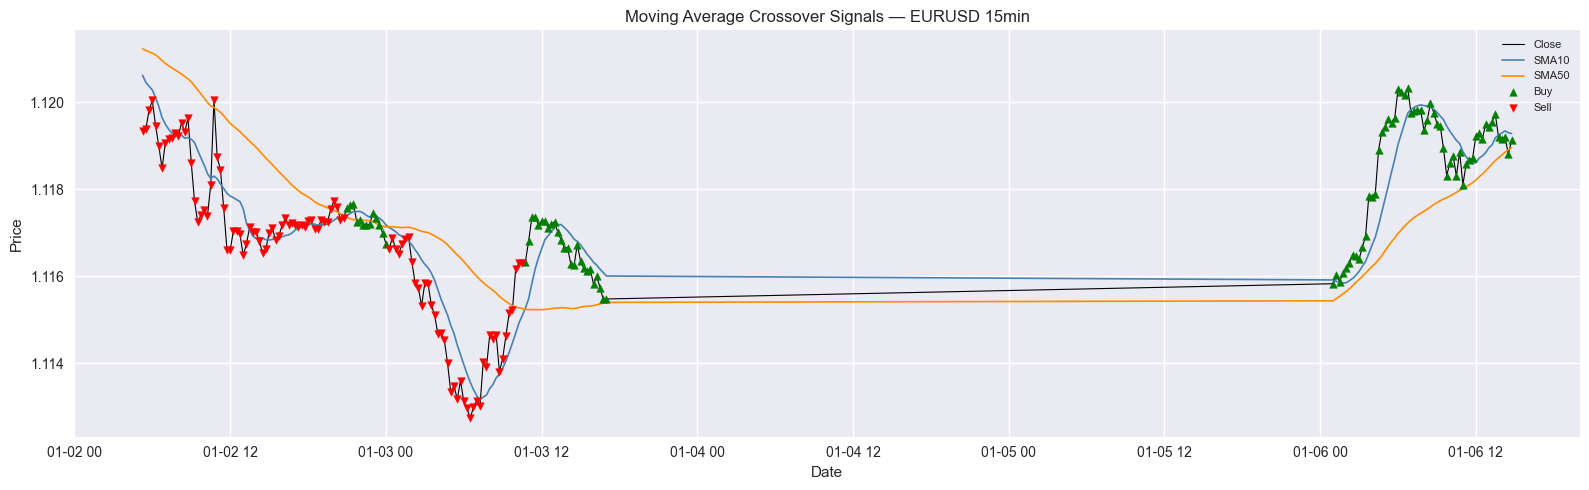

Saved: ma_signals.png


In [35]:
# MA Crossover signals — 200-bar window
window = eurusd_15min.iloc[:200].copy()
signal = np.where(window['SMA10'] > window['SMA50'], 1, -1)

buy_idx  = window.index[signal ==  1]
sell_idx = window.index[signal == -1]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(window.index, window['Close'],  color='black',      linewidth=0.8, label='Close')
ax.plot(window.index, window['SMA10'],  color='steelblue',  linewidth=1.2, label='SMA10')
ax.plot(window.index, window['SMA50'],  color='darkorange',  linewidth=1.2, label='SMA50')
ax.scatter(buy_idx,  window.loc[buy_idx,  'Close'],
           marker='^', color='green', s=30, zorder=5, label='Buy')
ax.scatter(sell_idx, window.loc[sell_idx, 'Close'],
           marker='v', color='red',   s=30, zorder=5, label='Sell')
ax.set_title('Moving Average Crossover Signals — EURUSD 15min', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'ma_signals.png'), dpi=150)
plt.show()
print('Saved: ma_signals.png')

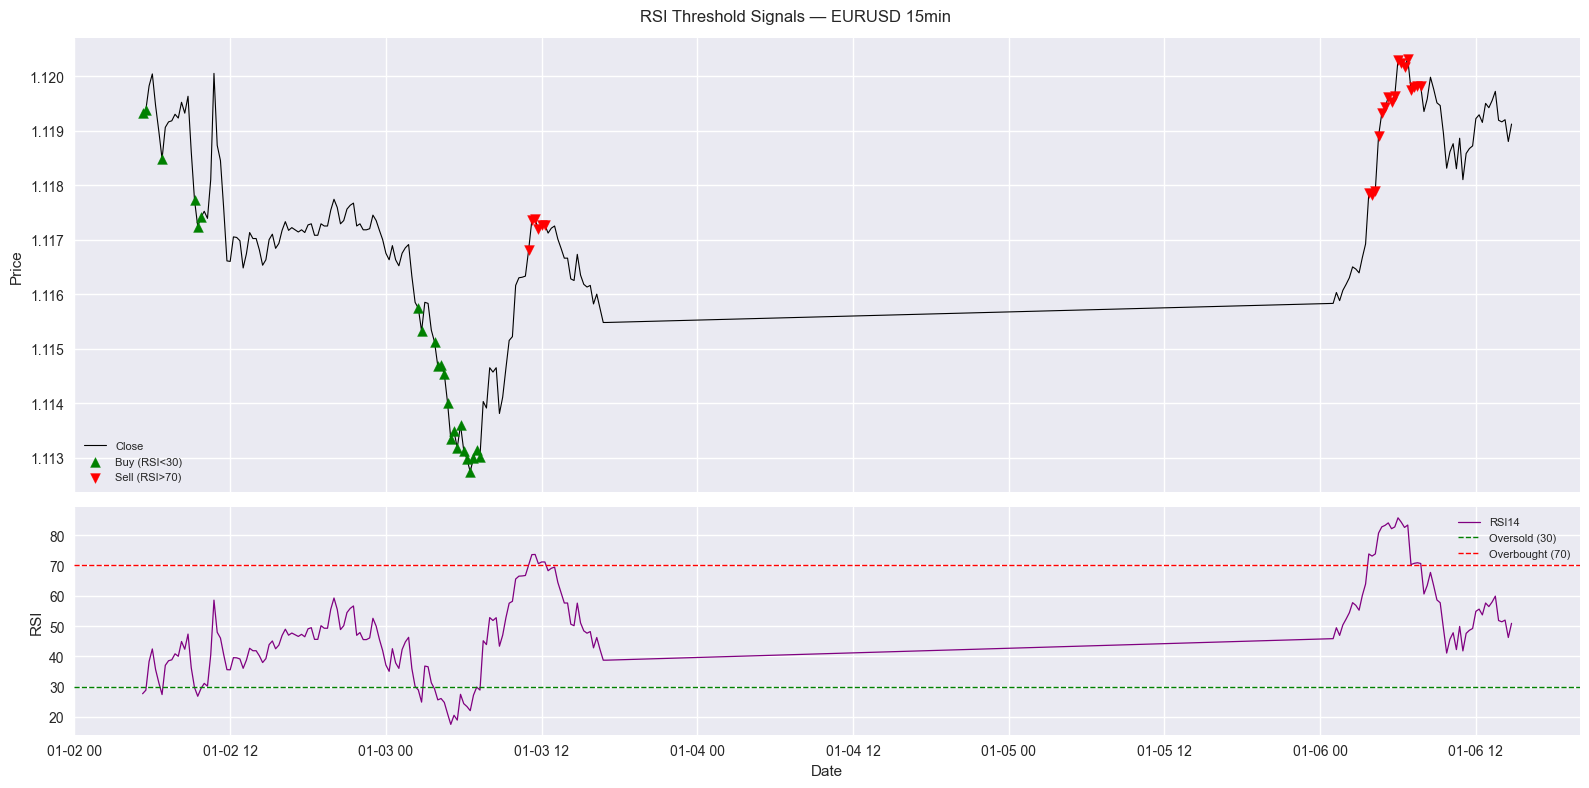

Saved: rsi_signals.png


In [36]:
# RSI signals — 200-bar window, two subplots
window = eurusd_15min.iloc[:200].copy()
rsi_signal = np.where(window['RSI14'] < RSI_OVERSOLD, 1,
             np.where(window['RSI14'] > RSI_OVERBOUGHT, -1, 0))

buy_idx  = window.index[rsi_signal ==  1]
sell_idx = window.index[rsi_signal == -1]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8),
                                 sharex=True, gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(window.index, window['Close'], color='black', linewidth=0.8, label='Close')
ax1.scatter(buy_idx,  window.loc[buy_idx,  'Close'],
            marker='^', color='green', s=50, zorder=5, label='Buy (RSI<30)')
ax1.scatter(sell_idx, window.loc[sell_idx, 'Close'],
            marker='v', color='red',   s=50, zorder=5, label='Sell (RSI>70)')
ax1.set_ylabel('Price')
ax1.legend(fontsize=8)

ax2.plot(window.index, window['RSI14'], color='purple', linewidth=0.9, label='RSI14')
ax2.axhline(RSI_OVERSOLD,   color='green', linestyle='--', linewidth=1.0, label=f'Oversold ({RSI_OVERSOLD})')
ax2.axhline(RSI_OVERBOUGHT, color='red',   linestyle='--', linewidth=1.0, label=f'Overbought ({RSI_OVERBOUGHT})')
ax2.set_ylabel('RSI')
ax2.set_xlabel('Date')
ax2.legend(fontsize=8)

fig.suptitle('RSI Threshold Signals — EURUSD 15min', fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'rsi_signals.png'), dpi=150)
plt.show()
print('Saved: rsi_signals.png')

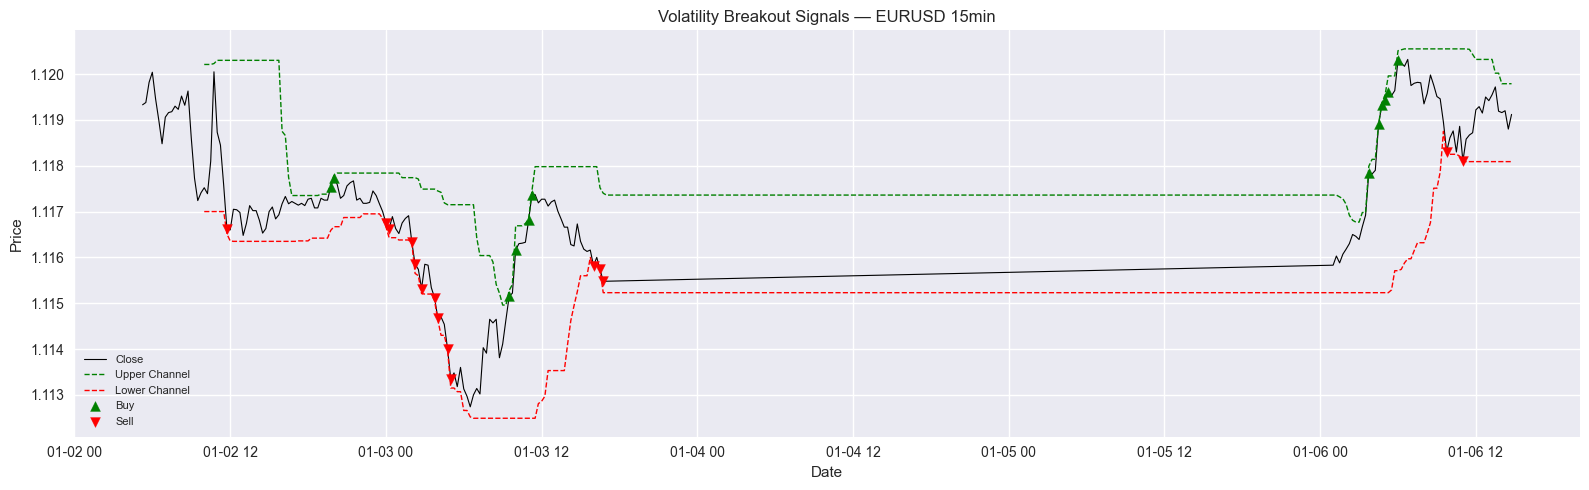

Saved: breakout_signals.png


In [37]:
# Volatility Breakout signals — 200-bar window
window = eurusd_15min.iloc[:200].copy()
upper  = window['High'].rolling(VB_K).max()
lower  = window['Low'].rolling(VB_K).min()

vb_signal = np.where(window['Close'] > upper.shift(1),  1,
            np.where(window['Close'] < lower.shift(1), -1, 0))

buy_idx  = window.index[vb_signal ==  1]
sell_idx = window.index[vb_signal == -1]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(window.index, window['Close'], color='black',     linewidth=0.8, label='Close')
ax.plot(window.index, upper,           color='green',     linewidth=1.0, linestyle='--', label='Upper Channel')
ax.plot(window.index, lower,           color='red',       linewidth=1.0, linestyle='--', label='Lower Channel')
ax.scatter(buy_idx,  window.loc[buy_idx,  'Close'],
           marker='^', color='green', s=50, zorder=5, label='Buy')
ax.scatter(sell_idx, window.loc[sell_idx, 'Close'],
           marker='v', color='red',   s=50, zorder=5, label='Sell')
ax.set_title('Volatility Breakout Signals — EURUSD 15min', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'breakout_signals.png'), dpi=150)
plt.show()
print('Saved: breakout_signals.png')

In [38]:
# Signal distribution summary table
full = eurusd_15min.copy()

ma_sig = np.where(full['SMA10'] > full['SMA50'], 1, -1)
rsi_sig = np.where(full['RSI14'] < RSI_OVERSOLD, 1,
          np.where(full['RSI14'] > RSI_OVERBOUGHT, -1, 0))
vb_upper = full['High'].rolling(VB_K).max()
vb_lower = full['Low'].rolling(VB_K).min()
vb_sig = np.where(full['Close'] > vb_upper.shift(1),  1,
         np.where(full['Close'] < vb_lower.shift(1), -1, 0))

sig_rows = []
for strat_name, sig in [('MA Crossover', ma_sig), ('RSI Threshold', rsi_sig), ('Volatility Breakout', vb_sig)]:
    sig_s = pd.Series(sig)
    total   = len(sig_s)
    n_buy   = (sig_s ==  1).sum()
    n_sell  = (sig_s == -1).sum()
    n_neut  = (sig_s ==  0).sum()
    sig_rows.append({
        'Strategy':          strat_name,
        'Total Signals':     total,
        'Buy (+1)':          n_buy,
        'Buy %':             f'{n_buy/total*100:.1f}%',
        'Sell (-1)':         n_sell,
        'Sell %':            f'{n_sell/total*100:.1f}%',
        'Neutral (0)':       n_neut,
        'Neutral %':         f'{n_neut/total*100:.1f}%',
    })

display(pd.DataFrame(sig_rows).set_index('Strategy'))

,Total Signals,Buy (+1),Buy %,Sell (-1),Sell %,Neutral (0),Neutral %
Strategy,,,,,,,
MA Crossover,114008,57286,50.2%,56722,49.8%,0,0.0%
RSI Threshold,114008,5473,4.8%,5534,4.9%,103001,90.3%
Volatility Breakout,114008,6727,5.9%,6561,5.8%,100720,88.3%
